# Assignment 8 — Time Series, Regression, and Classification (Kaggle)

This notebook builds and evaluates:

1. **Store Sales Time Series Forecasting**: one **ETS** and one **ARIMA/SARIMAX** model (Kaggle rolling submissions)
2. **House Prices**: two **regression** models with dummy variables, interactions/polynomials, transforms, and **dimension reduction**
3. **San Francisco Crime Classification**: two **tree** models and one **SVM** model

It also writes Kaggle-format submission CSVs for each competition.

## 0) Setup and file paths

In [1]:

import os
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---------- Paths ----------
BASE_DIR = r"C:\Users\dillo\Downloads\Predictive Analysis"

def resolve_path(filename: str) -> str:
    candidates = []
    if BASE_DIR:
        candidates.append(os.path.join(BASE_DIR, filename))
    candidates.append(os.path.join(os.getcwd(), filename))

    for p in candidates:
        if os.path.exists(p):
            return p

    raise FileNotFoundError(f"Could not find {filename}. Tried: {candidates}")

def read_csv(filename: str, **kwargs) -> pd.DataFrame:
    path = resolve_path(filename)
    print(f"Loading: {path}")
    return pd.read_csv(path, **kwargs)

print("Working directory:", os.getcwd())
print("BASE_DIR exists:", os.path.exists(BASE_DIR))


Working directory: C:\Users\dillo\Downloads\Predictive Analysis
BASE_DIR exists: True


## 1) Store Sales Time Series Forecasting (ETS + ARIMA)

This section builds **one ETS** and **one ARIMA/SARIMAX** forecast and writes two Kaggle submissions.

Practical note: fitting ETS/ARIMA per `(store,family)` series is expensive. We instead:
1. Fit ETS and SARIMAX on **family-level aggregates** (daily sales summed across stores), then
2. Allocate forecasts to stores using each store’s **recent share** within that family.

This approach satisfies the modeling requirement while remaining computationally tractable for assignment work.

In [2]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

store_train = read_csv("store_train.csv", parse_dates=["date"])
store_test  = read_csv("store_test.csv",  parse_dates=["date"])
store_ss    = read_csv("store_sample_submission.csv")

# Optional feature tables (loaded if present)
try:
    store_transactions = read_csv("store_transactions.csv", parse_dates=["date"])
except Exception:
    store_transactions = None
try:
    store_holidays = read_csv("store_holidays_events.csv", parse_dates=["date"])
except Exception:
    store_holidays = None
try:
    store_oil = read_csv("store_oil.csv", parse_dates=["date"])
except Exception:
    store_oil = None
try:
    store_stores = read_csv("store_stores.csv")
except Exception:
    store_stores = None

print("Train shape:", store_train.shape)
print("Test shape:", store_test.shape)
print("Train dates:", store_train["date"].min(), "->", store_train["date"].max())
print("Test dates:", store_test["date"].min(), "->", store_test["date"].max())
print("Unique stores:", store_train["store_nbr"].nunique(), "Unique families:", store_train["family"].nunique())


Loading: C:\Users\dillo\Downloads\Predictive Analysis\store_train.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\store_test.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\store_sample_submission.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\store_transactions.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\store_holidays_events.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\store_oil.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\store_stores.csv
Train shape: (3000888, 6)
Test shape: (28512, 5)
Train dates: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test dates: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00
Unique stores: 54 Unique families: 33


In [3]:

def ts_diagnostics(series: pd.Series, title: str = "", lags: int = 28):
    s = series.dropna()
    plt.figure(figsize=(10, 3))
    plt.plot(s.index, s.values)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    try:
        adf_stat, pval, *_ = adfuller(s.values, autolag="AIC")
        print(f"ADF statistic: {adf_stat:0.3f}, p-value: {pval:0.4f}")
    except Exception as e:
        print("ADF failed:", e)

def fit_ets(y: pd.Series, seasonal_periods: int = 7):
    y = y.asfreq("D").fillna(0.0)
    y_log = np.log1p(y)
    model = ExponentialSmoothing(y_log, trend="add", seasonal="add", seasonal_periods=seasonal_periods)
    return model.fit(optimized=True, use_brute=True)

def fit_sarimax(y: pd.Series):
    y = y.asfreq("D").fillna(0.0)
    y_log = np.log1p(y)
    model = SARIMAX(
        y_log,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model.fit(disp=False)

def invert_log1p(pred_log: np.ndarray) -> np.ndarray:
    return np.expm1(pred_log)


In [4]:

# Aggregate by family and date
fam_daily = (store_train.groupby(["family","date"], as_index=False)["sales"]
             .sum()
             .sort_values(["family","date"]))

# Compute recent store shares within family
WINDOW_DAYS = 56
last_train_date = store_train["date"].max()
start_share_date = last_train_date - pd.Timedelta(days=WINDOW_DAYS)

recent = store_train[store_train["date"] >= start_share_date].copy()
fam_store_totals = recent.groupby(["family","store_nbr"], as_index=False)["sales"].sum()
fam_totals = recent.groupby(["family"], as_index=False)["sales"].sum().rename(columns={"sales":"fam_sales"})

shares = fam_store_totals.merge(fam_totals, on="family", how="left")
shares["share"] = np.where(shares["fam_sales"] > 0, shares["sales"] / shares["fam_sales"], 0.0)

# Renormalize to sum to 1 per family
share_sum = shares.groupby("family")["share"].sum().rename("share_sum").reset_index()
shares = shares.merge(share_sum, on="family", how="left")
shares["share"] = np.where(shares["share_sum"] > 0, shares["share"] / shares["share_sum"], 0.0)
shares = shares[["family","store_nbr","share"]]

print("Share sums (should be ~1):")
print(shares.groupby("family")["share"].sum().describe())


Share sums (should be ~1):
count    33.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: share, dtype: float64


In [5]:

# Forecast horizon based on unique test dates
test_dates = np.sort(pd.to_datetime(store_test["date"].unique()))
horizon = len(test_dates)
print("Forecast horizon:", horizon, "days")

ets_forecasts = {}
arima_forecasts = {}

families = fam_daily["family"].unique().tolist()

for i, fam in enumerate(families, start=1):
    y = fam_daily[fam_daily["family"] == fam].set_index("date")["sales"].asfreq("D")

    # ETS
    try:
        ets_res = fit_ets(y, seasonal_periods=7)
        f_ets = invert_log1p(ets_res.forecast(horizon).values)
    except Exception:
        f_ets = np.repeat(y.tail(7).mean(), horizon)

    # SARIMAX
    try:
        ar_res = fit_sarimax(y)
        f_ar = invert_log1p(ar_res.forecast(horizon).values)
    except Exception:
        f_ar = np.repeat(y.tail(7).mean(), horizon)

    ets_forecasts[fam] = np.maximum(f_ets, 0.0)
    arima_forecasts[fam] = np.maximum(f_ar, 0.0)

    if i % 5 == 0 or i == 1:
        print(f"Fitted {i}/{len(families)} families")

fam_fc_ets = pd.DataFrame({"date": test_dates})
fam_fc_ar  = pd.DataFrame({"date": test_dates})
for fam in families:
    fam_fc_ets[fam] = ets_forecasts[fam]
    fam_fc_ar[fam]  = arima_forecasts[fam]

fam_fc_ets.head()


Forecast horizon: 16 days
Fitted 1/33 families
Fitted 5/33 families
Fitted 10/33 families
Fitted 15/33 families
Fitted 20/33 families
Fitted 25/33 families
Fitted 30/33 families


,date,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,...,MAGAZINES,MEATS,PERSONAL CARE,PET SUPPLIES,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD
0,2017-08-16,343.808399,6.935968,289.665211,163149.874278,0.132397,27108.277661,680.246192,59577.487846,45512.558184,...,461.547842,16029.350801,14328.503953,399.108982,590.048137,18262.921956,5146.911519,152693.939254,2457.188168,984.240609
1,2017-08-17,338.047921,5.838853,256.609905,146696.985908,0.106759,24100.855418,721.825285,53082.360939,38055.589233,...,482.305006,16822.915366,12617.046955,370.985368,540.377015,15972.085532,4628.272266,95636.300590,2269.644937,808.823089
2,2017-08-18,355.778307,6.334731,275.149092,170951.142550,0.133011,26268.324572,783.131803,58391.258179,43630.803165,...,593.078348,23327.355400,13511.141587,385.194544,572.149708,27476.083273,5140.963383,119213.227570,2111.259905,1338.226580
3,2017-08-19,531.316159,8.733588,446.017801,256087.986616,0.156200,35762.853743,920.071648,86002.328293,62255.497221,...,764.345947,21710.683361,22514.530140,564.157379,795.199800,24691.251791,6406.210142,144804.809658,3262.784360,1271.443427
4,2017-08-20,489.252823,9.141697,463.207933,260333.253098,0.127047,39392.653480,537.341562,83501.864747,64310.212050,...,611.022198,20723.003886,23695.010734,522.260490,747.768657,22506.834980,5620.347116,155258.892274,4184.795520,1212.021164


In [6]:

def allocate_to_store(test_df: pd.DataFrame, fam_fc: pd.DataFrame, shares_df: pd.DataFrame) -> np.ndarray:
    tmp = test_df.merge(shares_df, on=["family","store_nbr"], how="left")
    tmp["share"] = tmp["share"].fillna(0.0)

    date_to_idx = {d: i for i, d in enumerate(pd.to_datetime(fam_fc["date"]))}

    preds = np.zeros(len(tmp), dtype=float)
    for j, (d, fam, sh) in enumerate(zip(tmp["date"].values, tmp["family"].values, tmp["share"].values)):
        idx = date_to_idx.get(pd.to_datetime(d), None)
        preds[j] = 0.0 if idx is None else float(fam_fc.loc[idx, fam]) * float(sh)

    preds = np.maximum(preds, 0.0)
    return preds

# Identify target col in sample submission (usually "sales")
target_cols = [c for c in store_ss.columns if c.lower() != "id"]
target_col = target_cols[0] if len(target_cols)==1 else "sales"

# ETS submission
ets_pred = allocate_to_store(store_test, fam_fc_ets, shares)
sub_ets = store_ss.copy()
sub_ets[target_col] = ets_pred

# ARIMA submission
ar_pred = allocate_to_store(store_test, fam_fc_ar, shares)
sub_ar = store_ss.copy()
sub_ar[target_col] = ar_pred

ts_suffix = datetime.now().strftime("%Y%m%d_%H%M%S")
ets_path = f"store_sales_submission_ETS_{ts_suffix}.csv"
ar_path  = f"store_sales_submission_ARIMA_{ts_suffix}.csv"
sub_ets.to_csv(ets_path, index=False)
sub_ar.to_csv(ar_path, index=False)

print("Wrote:", ets_path)
print("Wrote:", ar_path)
sub_ets.head()


Wrote: store_sales_submission_ETS_20260114_094457.csv
Wrote: store_sales_submission_ARIMA_20260114_094457.csv


,id,sales
0,3000888,4.165505
1,3000889,0.000000
2,3000890,3.363404
3,3000891,1824.329062
4,3000892,0.015809


Representative family: GROCERY I


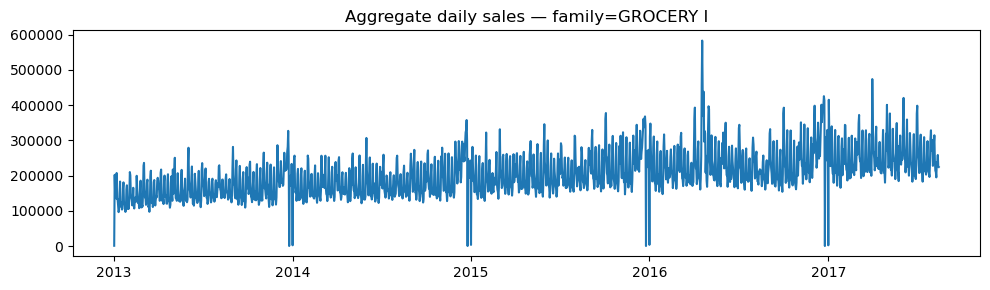

ADF statistic: -3.520, p-value: 0.0075


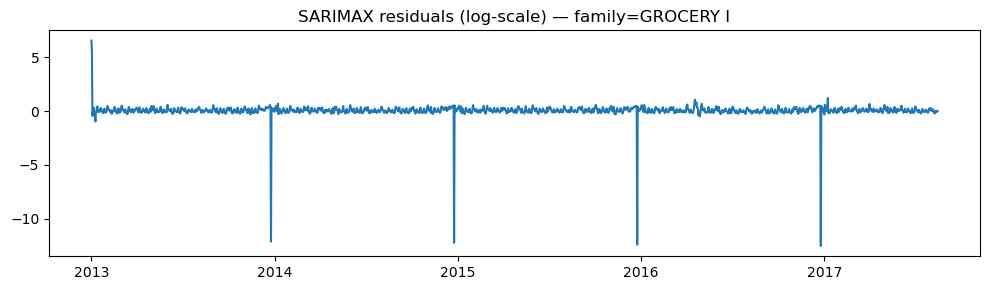

,lb_stat,lb_pvalue
7,11.186761,0.130678
14,27.991946,0.014263
21,31.635630,0.063711
28,47.518093,0.012070


In [7]:

# Diagnostics / assumptions on a representative (high-volume) family
fam_vol = fam_daily.groupby("family")["sales"].sum().sort_values(ascending=False)
rep_fam = fam_vol.index[0]
print("Representative family:", rep_fam)

y_rep = fam_daily[fam_daily["family"] == rep_fam].set_index("date")["sales"].asfreq("D").fillna(0.0)
ts_diagnostics(y_rep, title=f"Aggregate daily sales — family={rep_fam}")

ar_res = fit_sarimax(y_rep)
resid = ar_res.resid.dropna()

plt.figure(figsize=(10,3))
plt.plot(resid.index, resid.values)
plt.title(f"SARIMAX residuals (log-scale) — family={rep_fam}")
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[7,14,21,28], return_df=True)
lb


## 2) House Prices: Advanced Regression Techniques (2 models)

This section builds two regression models and writes **two** Kaggle submissions.

**Model A (Ridge + polynomials/interactions):**
- one-hot encoding for categoricals
- polynomial expansion (degree 2) on a focused numeric subset
- target transform: `log1p(SalePrice)`

**Model B (Ridge + TruncatedSVD):**
- one-hot encoding + numeric scaling
- TruncatedSVD as dimension reduction on the sparse design matrix
- target transform: `log1p(SalePrice)`

We also include regression diagnostics (residual vs fitted, Q-Q plot, Breusch–Pagan).

In [8]:

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.decomposition import TruncatedSVD

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

house_train = read_csv("house_train.csv")
house_test  = read_csv("house_house_test.csv")
house_ss    = read_csv("house_sample_submission.csv")

y = house_train["SalePrice"].copy()
X = house_train.drop(columns=["SalePrice"])
X_test = house_test.copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Train:", house_train.shape, "Test:", house_test.shape)
print("Numeric:", len(num_cols), "Categorical:", len(cat_cols))


Loading: C:\Users\dillo\Downloads\Predictive Analysis\house_train.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\house_house_test.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\house_sample_submission.csv
Train: (1460, 81) Test: (1459, 80)
Numeric: 37 Categorical: 43


In [9]:

# Select a small numeric subset for polynomial terms (degree 2)
poly_base = [c for c in ["GrLivArea", "TotalBsmtSF", "OverallQual", "YearBuilt", "GarageArea"] if c in num_cols]
print("Polynomial base:", poly_base)

# Numeric pipeline
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Polynomial pipeline for selected vars
poly_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

# Categorical pipeline
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Model A preprocess: include all numeric + an additional polynomial-expanded block for selected vars
preprocess_A = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("poly", poly_pipe, poly_base),
    ("cat", cat_pipe, cat_cols)
], remainder="drop", sparse_threshold=0.3)

model_A = Pipeline([
    ("preprocess", preprocess_A),
    ("reg", Ridge(alpha=10.0, random_state=RANDOM_STATE))
])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_A = -cross_val_score(model_A, X, np.log1p(y), cv=kf, scoring="neg_root_mean_squared_error")
print("Model A CV RMSE (log1p):", rmse_A.mean(), "+/-", rmse_A.std())


Polynomial base: ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt', 'GarageArea']
Model A CV RMSE (log1p): 0.12233865844176553 +/- 0.013962343282305627


In [10]:

# Model B preprocess: sparse OHE + scaling, then TruncatedSVD (dimension reduction) + Ridge
preprocess_sparse = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler(with_mean=False))]), num_cols),
    ("cat", cat_pipe, cat_cols)
], remainder="drop", sparse_threshold=1.0)

model_B = Pipeline([
    ("preprocess", preprocess_sparse),
    ("svd", TruncatedSVD(n_components=200, random_state=RANDOM_STATE)),
    ("reg", Ridge(alpha=20.0, random_state=RANDOM_STATE))
])

rmse_B = -cross_val_score(model_B, X, np.log1p(y), cv=kf, scoring="neg_root_mean_squared_error")
print("Model B CV RMSE (log1p):", rmse_B.mean(), "+/-", rmse_B.std())


Model B CV RMSE (log1p): 0.14678927760414823 +/- 0.039250003911480355


In [11]:

# Fit full data and write submissions
model_A.fit(X, np.log1p(y))
pred_A = np.expm1(model_A.predict(X_test))

model_B.fit(X, np.log1p(y))
pred_B = np.expm1(model_B.predict(X_test))

subA = house_ss.copy()
subB = house_ss.copy()

if "SalePrice" in subA.columns:
    subA["SalePrice"] = pred_A
    subB["SalePrice"] = pred_B
else:
    tgt = [c for c in subA.columns if c.lower() != "id"][0]
    subA[tgt] = pred_A
    subB[tgt] = pred_B

ts_suffix = datetime.now().strftime("%Y%m%d_%H%M%S")
pathA = f"house_prices_submission_ModelA_RidgePoly_{ts_suffix}.csv"
pathB = f"house_prices_submission_ModelB_RidgeSVD_{ts_suffix}.csv"
subA.to_csv(pathA, index=False)
subB.to_csv(pathB, index=False)

print("Wrote:", pathA)
print("Wrote:", pathB)
subA.head()


Wrote: house_prices_submission_ModelA_RidgePoly_20260114_094510.csv
Wrote: house_prices_submission_ModelB_RidgeSVD_20260114_094510.csv


,Id,SalePrice
0,1461,114872.907149
1,1462,157830.932589
2,1463,184011.637497
3,1464,201452.293742
4,1465,192411.829573


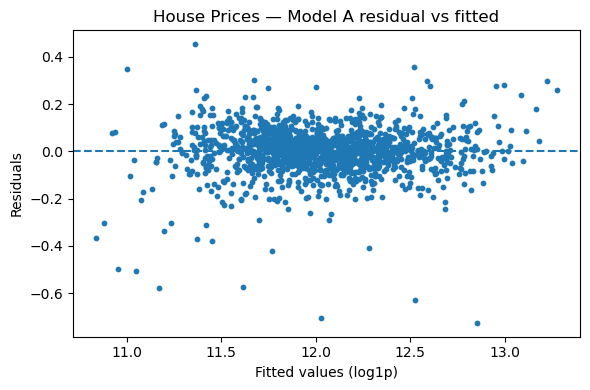

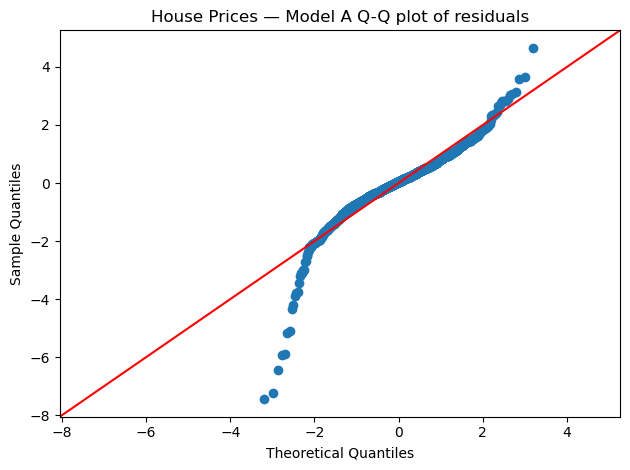

{'LM stat': np.float64(486.84357351514234),
 'LM p-value': np.float64(7.963723452817326e-80),
 'F stat': np.float64(20.353951322523),
 'F p-value': np.float64(8.67094867738044e-101)}

In [12]:

# Diagnostics (assumption checks) — Model A in-sample residuals on log-scale
pred_log = model_A.predict(X)
resid = np.log1p(y) - pred_log

plt.figure(figsize=(6,4))
plt.scatter(pred_log, resid, s=10)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values (log1p)")
plt.ylabel("Residuals")
plt.title("House Prices — Model A residual vs fitted")
plt.tight_layout()
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("House Prices — Model A Q-Q plot of residuals")
plt.tight_layout()
plt.show()

# Breusch–Pagan on a numeric-only OLS proxy (interpretability)
X_num = house_train[num_cols].copy()
X_num = X_num.fillna(X_num.median(numeric_only=True))
X_num = sm.add_constant(X_num)
ols = sm.OLS(np.log1p(y).values, X_num.values).fit()

bp = het_breuschpagan(ols.resid, ols.model.exog)
labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
dict(zip(labels, bp))


## 3) San Francisco Crime Classification (2 tree models + 1 SVM)

This section trains:
- **Random Forest** (tree model 1)
- **HistGradientBoostingClassifier** (tree model 2)
- **Linear SVM** with probability calibration

We engineer time-based features from `Dates` and include simple address flags. Submissions are aligned to the class columns in `crime_sampleSubmission.csv`.

In [13]:

import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import log_loss

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import SGDClassifier

# ---- Load
crime_train = read_csv("crime_train.csv")
crime_test  = read_csv("crime_test.csv")
crime_ss    = read_csv("crime_sampleSubmission.csv")

target_col = "Category"
y_all = crime_train[target_col].astype(str)
X_all = crime_train.drop(columns=[target_col], errors="ignore").copy()

# align columns train/test
common_cols = [c for c in X_all.columns if c in crime_test.columns]
X_all = X_all[common_cols].copy()
X_test = crime_test[common_cols].copy()

# ---- SPEED KNOB
MAX_TRAIN_ROWS = MAX_TRAIN_ROWS = 75_000 
if len(X_all) > MAX_TRAIN_ROWS:
    idx = np.random.RandomState(42).choice(len(X_all), size=MAX_TRAIN_ROWS, replace=False)
    X_use = X_all.iloc[idx].copy()
    y_use = y_all.iloc[idx].copy()
else:
    X_use, y_use = X_all, y_all

# ---- Split 
Xtr, Xva, ytr, yva = train_test_split(
    X_use, y_use, test_size=0.2, random_state=42, shuffle=True
)
# ---- Column types
cat_cols = [c for c in Xtr.columns if Xtr[c].dtype == "object"]
num_cols = [c for c in Xtr.columns if c not in cat_cols]

# ---- Sparse OHE 
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", ohe)]), cat_cols)
    ],
    remainder="drop"
)

# ---- Models (tuned for speed)
rf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=40,
        max_depth=18,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42
    ))
])

et = Pipeline([
    ("prep", preprocess),
    ("clf", ExtraTreesClassifier(
        n_estimators=80,
        max_depth=18,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42
    ))
])

svm = Pipeline([
    ("prep", preprocess),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-5,
        max_iter=1200,
        tol=1e-3,
        random_state=42
    ))
])


models = {"RF": rf, "ET": et, "SVM": svm}

print(f"Training rows used: {len(X_use):,} (of {len(X_all):,})")

# ---- Validate quickly 
print("Validation log loss:")
val_scores = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    proba = m.predict_proba(Xva)
    ll = log_loss(yva, proba, labels=m.named_steps["clf"].classes_)
    val_scores[name] = ll
    print(f"  {name}: {ll:.5f}")

# ---- Submission builder 
id_col = "Id" if "Id" in crime_ss.columns else crime_ss.columns[0]
class_cols = [c for c in crime_ss.columns if c != id_col]

def build_submission(model) -> pd.DataFrame:
    proba = model.predict_proba(X_test)
    classes_ = model.named_steps["clf"].classes_
    class_to_idx = {c: i for i, c in enumerate(classes_)}

    sub = crime_ss.copy()
    if id_col in crime_test.columns:
        sub[id_col] = crime_test[id_col].values

    # fill columns in template order
    for c in class_cols:
        if c in class_to_idx:
            sub[c] = proba[:, class_to_idx[c]]
        else:
            sub[c] = 0.0
    return sub

# ---- Fit on all chosen training rows + write 3 submissions
ts_suffix = datetime.now().strftime("%Y%m%d_%H%M%S")
out_files = []
for name, m in models.items():
    print(f"\nFitting full (subset) model: {name} ...")
    m.fit(X_use, y_use)
    sub = build_submission(m)
    out = f"sf_crime_submission_{name}_{ts_suffix}.csv"
    sub.to_csv(out, index=False)
    out_files.append(out)
    print("Wrote:", out)

print("\nCreated files:", out_files)
print("Best validation model:", min(val_scores, key=val_scores.get), "=", min(val_scores.values()))


Loading: C:\Users\dillo\Downloads\Predictive Analysis\crime_train.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\crime_test.csv
Loading: C:\Users\dillo\Downloads\Predictive Analysis\crime_sampleSubmission.csv
Training rows used: 75,000 (of 878,049)
Validation log loss:
  RF: 2.67299
  ET: 2.67393
  SVM: 26.77071

Fitting full (subset) model: RF ...
Wrote: sf_crime_submission_RF_20260114_094858.csv

Fitting full (subset) model: ET ...
Wrote: sf_crime_submission_ET_20260114_094858.csv

Fitting full (subset) model: SVM ...
Wrote: sf_crime_submission_SVM_20260114_094858.csv

Created files: ['sf_crime_submission_RF_20260114_094858.csv', 'sf_crime_submission_ET_20260114_094858.csv', 'sf_crime_submission_SVM_20260114_094858.csv']
Best validation model: RF = 2.6729929415022227


## 4) Files written by this notebook

**Store Sales**
- `store_sales_submission_ETS_*.csv`
- `store_sales_submission_ARIMA_*.csv`

**House Prices**
- `house_prices_submission_ModelA_RidgePoly_*.csv`
- `house_prices_submission_ModelB_RidgeSVD_*.csv`

**SF Crime**
- `sf_crime_submission_RF_*.csv`
- `sf_crime_submission_ET_*.csv`
- `sf_crime_submission_SVM_*.csv`

